# Playground

## Modules

In [1]:
from typing import Tuple
from functools import reduce
from collections import Counter
import random
import re

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T

import numpy as np
import matplotlib.pyplot as plt
import PIL

In [51]:
print("PyTorch version:", torch.__version__)

In [3]:
torch.manual_seed(71)

## RegEx

In [ ]:
n = 1213
filename = f"ILSVRC2012_val_{n:08d}.JPEG"
print("Filename:", filename)
m = re.match(r"^ILSVRC2012_val_([^.]+)\.JPEG$", filename)
if m is None:
    raise ValueError(f"Invalid filename format: {filename}")
assert int(m.group(1)) == n, f"Expected {n}, but got {int(m.group(1))}"
print("OK")

Filename: ILSVRC2012_val_00001213.JPEG
OK


In [36]:
n = 1213
filename = f"ILSVRC2012_val_{n:08d}_n02066245.JPEG"
print("Filename:", filename)
m = re.match(r"^[^_]+_[^_]+_([^_]+)_[^.]+\.JPEG$", filename)
if m is None:
    raise ValueError(f"Invalid filename format: {filename}")
assert int(m.group(1)) == n, f"Expected {n}, but got {int(m.group(1))}"
print("OK")

Filename: ILSVRC2012_val_00001213_n02066245.JPEG
OK


## Collections.Counter

In [12]:
counter = Counter()
counter.update(['a', 'b', 'b', 'c', 'c', 'c'])
print(counter)

## Tests avec String

In [7]:
print("test".rjust(10, " "))
print("test".ljust(10, " "))
print(("abc"*40).ljust(10, " ")[:30])

## Test avec PyTorch

### Tests sur l'indexation des tenseurs 

#### Tenseur comme indice utilisé avec un autre tenseur

In [ ]:
t = torch.arange(1, 21)
t1 = t.view(4, -1)
print(t1)
print(t1.size())

In [ ]:
i1 = torch.tensor([1, 1])
print("i1:", i1)
print("t1[i1] :", t1[i1], " de dimension ", t1[i1].size())
print("t1[*i1] :", t1[*i1], " de dimension ", t1[*i1].size())

`t1[i1]` est composé de t1[1] et t1[1]
`t1[*i1]` est composé de t1[1, 1]

In [ ]:
i2 = torch.tensor([[1, 1], [2, 1]])
print("i2:", i2, " de dimension ", i2.size())
print("t1[i2] :", t1[i2], " de dimension ", t1[i2].size())
print("*i2", *i2)
print("t1[*i2] :", t1[*i2], " de dimension ", t1[*i2].size())

i2b = torch.tensor([[1, 3], [1, 2]])
print("i2b:", i2b)
print("*i2b", *i2b)
print("t1[*i2b] :", t1[*i2b])

`t1[i2]` est composé comme [[t[1], t[1]], [t[2], t[1]]] : 4 lignes
`t1[*i2]` est composé de t1[1, 2] et t1[1, 1]
`t1[*i2b]` est composé de t1[1, 1] et t1[3, 2]

In [ ]:
t2 = t.view(2, 2, -1)
print(t2)
print(t2.size())

In [ ]:
print("i1:", i1)
print("t2[i1] :", t2[i1])
print("t2[*i1] :", t2[*i1])

print("i2:", i2)
print("t1[*i2] :", t1[*i2])

In [ ]:
i3 = torch.tensor([[0, 1, 0], [1, 1, 0]])
print(t2[i3])

Chaque valeur de i3 doit être compatible avec la taille de la première dimension de t2

In [ ]:
print(t2[*i3])
print(t2[0, 1], t2[1, 1], t2[0, 0])

In [ ]:
print(i3)
print(i3.T)

In [ ]:
i4 = torch.tensor([[0, 1, 0], [1, 1, 0], [2, 2, 2]])
print(i4.size())
print(t2[*i4])
print(t2[0, 1, 2], t2[1, 1, 2], t2[0, 0, 2])

In [ ]:
print(i4)
print(i4.T)

En utilisant l'opérateur `*`, les coordonnées de chaque élément formant le tenseur résultant correspondent aux vecteurs de la dernière dimension de la transposée.
Ce qui signifie que la matrice des indices doit respecter à la fois le nombre de dimensions et leurs tailles respectives :

pour un tenseur de valeurs $t \in \mathbb{R}^n$, il faut que le tenseur d'indices $i \in \mathbb{R}^m$, en base 1 ($r$ : *row*, $c$ : *column*) :
- a priori $m \le 2$ pour maîtriser l'estimation le résultat
- $i_{r,c} \le s_1$ avec $\text{shape}(t) = (s_1, s_2, \dots, s_n)$ si utilisation directe
- $\text{shape}(i^{\top})_2 \le n$ et $i^{\top}_{r, c} \le s_c$ si utilisation avec 
    - i.e $|\text{shape}(i)_1| \le n$


Voir doc de Numpy : [beginner : Indexing and slicing](https://numpy.org/doc/2.2/user/absolute_beginners.html#indexing-and-slicing), [Indexing, slicing and iterating](https://numpy.org/doc/2.2/user/quickstart.html#indexing-slicing-and-iterating) puis [Indexing on ndarrays](https://numpy.org/doc/2.2/user/basics.indexing.html#basics-indexing).

In [ ]:
t = torch.arange(0, 3*3*3).view(3, 3, 3)
print(t)

i = torch.tensor([[0, 1], [1, 2]])
print(t[i])
print(t[*i.T])

print(t[*i.unsqueeze(dim=0).mT])

#### Slice

In [ ]:
size = d1, d2, d3 = 4, 6, 5
n = reduce(lambda x,y : x*y, size)
t = torch.arange(0, n).view(size)
print(t)

print(t[1::2, 2::3, ::2])

In [ ]:
t
t[1::2]

#### Addition sur une seule colonne d'un tenseur 2d

In [ ]:
batch_input = torch.zeros(5, 1, 1)

coord = [
        [0, 1, 1, 1],
        [0, 2, 1, 1],
        [0, 60, 50, 50]
    ]
t = torch.tensor(coord).repeat(batch_input.size(0), 1)

print(t)
print(t[:, 0])

a = torch.arange(0, batch_input.size(0)).view(batch_input.size(0), 1).repeat(1, t.size(1)-1).flatten()
print(a)
t[:, 0] += a
print(t)

### Test de `torch.repeat`

In [13]:
x = torch.tensor([1, 2, 3])
print(x)
print(x.size())

In [14]:
y = x.repeat(4, 2)
print(y)
print(y.size())

In [15]:
y = x.repeat(4, 1)
print(y)
print(y.size())

In [16]:
y = x.repeat(4, 3, 1)
print(y)
print(y.size())

In [17]:
n = 5
t = torch.arange(0, n**2).reshape(n, n)
print(t)
print(t.size())

In [18]:
y = t.repeat(1, 3, 1, 1)
print(y)
print(y.size())

In [19]:
z = torch.tensor([10, 100, 1000]).unsqueeze(dim=0).unsqueeze(dim=0).reshape(3, 1, 1).unsqueeze(dim=0)
print(z)
print(z.size())
print(z+t)

### Tests de `torch.where`

In [ ]:
torch.where(t % 2 == 0, 0, 1)

In [ ]:
torch.where(t % 2 != 0, 0., 1.)

In [ ]:
torch.where(t % 2 != 0, 0., 1.).unsqueeze(0).unsqueeze(0).size()

### Tests de `torch.MaxUnpool2d`

In [ ]:
pool = nn.MaxPool2d(2, stride=2, return_indices=True)
unpool = nn.MaxUnpool2d(2, stride=2)
input = torch.tensor([[[[ 1.,  2.,  3.,  4.],
                        [ 5.,  6.,  7.,  8.],
                        [ 9., 10., 11., 12.],
                        [13., 14., 15., 16.]]]])

output, indices = pool(input)
print(output)
print(indices)

In [ ]:
unpool(output, indices)

In [ ]:
pool.return_indices = False
print(pool(input))

In [ ]:
nn.functional.max_unpool2d(output, indices, kernel_size=2, stride=2)

In [ ]:
output.size()

In [ ]:
t = torch.zeros_like(output)
t[0, 0, 0, 0] = 6
nn.functional.max_unpool2d(t, indices, kernel_size=2, stride=2)

In [ ]:
# Now using output_size to resolve an ambiguous size for the inverse
input = torch.tensor([[[[ 1.,  2.,  3.,  4.,  5.],
                        [ 6.,  7.,  8.,  9., 10.],
                        [11., 12., 13., 14., 15.],
                        [16., 17., 18., 19., 20.]]]])
pool.return_indices = True
output, indices = pool(input)
# This call will not work without specifying output_size
unpool(output, indices, output_size=input.size())


In [ ]:
t = torch.rand((1, 64, 55, 55))
idx = torch.randperm(t.shape[0])
t = t[idx].view(t.size())
print(t.size())
p = nn.MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False, return_indices=True)
o, indices = p(t)
print(o.size(), indices.size())
o[0, 6, 5, 9] = 15.879010200500488
o = nn.functional.max_unpool2d(o, indices, kernel_size=3, stride=2, padding=0)
print(o.size())
print(o.max().item())

In [ ]:
#t = torch.arange(64*55*55).reshape((1, 64, 55, 55)).float()
t = torch.full((1, 64, 55, 55), 1.)
p = nn.MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False, return_indices=True)
o, indices = p(t)
print(indices.size())
o = torch.zeros_like(o)
o[0, 6, 5, 9]=1.
u = nn.functional.max_unpool2d(o, indices, kernel_size=3, stride=2, padding=0)
print(u.size())
print(u.max())


### Tests de `torch.nonzero`

In [ ]:
# Now using output_size to resolve an ambiguous size for the inverse
t = torch.tensor([[[[ 1.,  2.,  5.,  4.,  5.],
                    [ 6.,  7.,  8.,  9., 10.],
                    [11., 12., 13., 14., 15.],
                    [16., 17., 18., 19., 20.]]]])
print(t.size())
i = (t == 5).nonzero(as_tuple=False)
print(i)

In [ ]:
t2 = torch.zeros_like(t)
t2[0, 0, 0, 4] = 1
t2

In [ ]:
value = 5
i = (t == value).nonzero(as_tuple=True)
print(i)
t2[*i] = value
print(t2)


### Tests pour nettoyer un tenseur

In [ ]:
t = torch.arange(1, 21).view(2, -1)
v = 10
print(t==v)

In [ ]:
t * (t==v)

### Tests avec `torch.tensor.size`

In [ ]:
t1 = torch.arange(1, 21).view(2, -1)
t2 = torch.ones_like(t1)
t3 = torch.arange(1,5)

print(t1.size())
print(t2.size())
print(t1.size() == t2.size())
print(t1.size() == t3.size())

In [ ]:
list(t1.size())

In [ ]:
t[0, 0].size()[0]

### Tests de `torch.unique`

In [ ]:
t = torch.ones((10)).view(2, -1)
t[1, 3] = 10
print(torch.unique(t))

### Tests de `torch.full`

In [ ]:
print(torch.full((10,), 10))

### Tests avec `torch.Tensor.max()`

In [ ]:
torch.tensor([1, 2, 3]).max()

### Tests avec `torch.Tensor.item()`

In [ ]:
t = torch.arange(1, 11).view(-1, 1)
print(t)
print(t.ravel().tolist())

### Tests avec ConvTranspose2d

In [64]:
# (N, C, H, W)
input = torch.randn(1, 4, 5, 5)
#print(input)

# Création de la convolution
conv = nn.Conv2d(in_channels=4, out_channels=8, kernel_size=3, stride=2, padding=1, bias=False)

# Initialisation des poids avec la matrice identité pour chaque canal
with torch.no_grad():
    for i in range(min(conv.in_channels, conv.out_channels)):
        conv.weight[i, i] = torch.eye(conv.kernel_size[0])
print("Weight conv:", conv.weight.size())
#print("Bias:", conv.bias.size(), conv.bias)

deconv = nn.ConvTranspose2d(
    in_channels=conv.out_channels,
    out_channels=conv.in_channels,
    kernel_size=conv.kernel_size,
    stride=conv.stride,
    padding=conv.padding,
    bias=False
)
print("Weight deconv:", deconv.weight.size())

with torch.no_grad():
    for i in range(deconv.in_channels):
        for j in range(deconv.out_channels):
            deconv.weight[i, j] = conv.weight[i, j]
print(torch.equal(conv.weight, deconv.weight))

with torch.no_grad():
    h = conv(input)
    print("h:", h.size())
    output_1 = deconv(h, output_size=input.size())
    print("output 1:", output_1.size())

    output_size = input.size()
    num_spatial_dims = 2
    output_padding = deconv._output_padding(
        h,
        output_size,
        deconv.stride,  # type: ignore[arg-type]
        deconv.padding,  # type: ignore[arg-type]
        deconv.kernel_size,  # type: ignore[arg-type]
        num_spatial_dims,
        deconv.dilation,  # type: ignore[arg-type]
    )
    print("output_padding:", output_padding)
    
    output_2 = nn.functional.conv_transpose2d(h, deconv.weight, deconv.bias, stride=deconv.stride, padding=deconv.padding, output_padding=output_padding, groups=1)
    print("output 2:", output_2.size())

    print(torch.equal(output_1, output_2))
    print(output_1)
    print(output_2)

    output_3 = nn.functional.conv_transpose2d(h, conv.weight, deconv.bias, stride=conv.stride, padding=conv.padding, output_padding=output_padding, groups=1)
    print(torch.equal(output_1, output_3))


In [52]:
h.dim()

### Torch.flip

In [65]:
t = torch.arange(1, 21).view(2, -1)
print(t)

In [68]:
t_flipped = torch.flip(t, [1,0])
print(t_flipped)
print(t)

### Tests avec `torch.topk`

Motivations : récupérer les plus $k$ grandes activations par batch, ou par canal.

In [96]:
random.seed(71)

b, ch, row, col = 2, 3, 4, 5
l = list(range(0, b*ch*row*col))
random.shuffle(l)
print(l)

t = torch.tensor(l).reshape((b, ch, row, col))
print(t)

Par batch :

In [134]:
k = 2
t_flat = torch.flatten(t, start_dim=1)
print(t_flat)
batch_values, batch_indices = t_flat.topk(k, dim=1)
print("values:", batch_values)
print("indices:", batch_indices)

coord = lambda i: [i // (row * col), (i // col) % row, i % col]
indices2 = torch.tensor([[coord(i.item()) for i in b] for b in batch_indices])
print("indices2:", indices2)

for b in range(t.size(0)):
    for i in indices2[b, :]:
        print(i, t[b][*i])

Par canal:

In [133]:
k = 2
t_flat = torch.flatten(t, start_dim=2)
print(t_flat)
batch_values, batch_indices = t_flat.topk(k, dim=2)
print("values:", batch_values)
print("indices:", batch_indices)

coord = lambda i_ch, i: [i_ch, i // col, i % col]
indices2 = torch.tensor([[[coord(i_ch, i.item()) for i in ch] for i_ch, ch in enumerate(b)] for b in batch_indices])
print("indices2:", indices2)

for b in range(t.size(0)):
        for i in indices2[b, :].flatten(start_dim=0, end_dim=-2):
            print(i, t[b][*i])

## Tests de `zip`

In [20]:
list1 = [3, 2, 4, 1, 1]
list2 = ['three', 'two', 'four', 'one', 'one2']
list1, list2 = (list(reversed(t)) for t in zip(*sorted(zip(list1, list2))))

print(list1)
print(list2)

In [21]:
print(str(list(zip(list1, list2))))

In [22]:
d = {
    (0, 0, 0): "0, 0, 0",
    (0, 1, 1): "0, 1, 1",
    (1, 0, 0): "1, 0, 0",
}

In [23]:
for k in d.keys():
    print(k[0])

In [24]:
d1 = {
    1: "1",
    2: "2",
    3: "3"
}
print(4 in d1.keys())

In [25]:
for i in d1:
    print(i)

In [26]:
rng = np.random.default_rng()
n = rng.integers(10)
print(n, rng.choice(10, n, replace=False))

In [27]:
l = [(0, 0, 0), (0, 1, 0)]
l

In [28]:
print((0, 0, 0) in l)
print((0, 1, 0) in l)
print((0, 2, 0) in l)

## Tests avec `PIL`

In [47]:
print(PIL.__version__)

In [48]:
tensor = torch.rand(3,256,256)

In [49]:
transform = T.ToPILImage()

In [50]:
img = transform(tensor)

In [51]:
# display img
img

In [52]:
from PIL import Image

In [53]:
im = Image.open("Grace_Hopper.jpg")
print(im.format, im.size, im.mode)

In [54]:
im.show()

In [55]:
from torchvision.io import read_image

In [56]:
import os

In [57]:
DataPath = "/Users/me/Documents/Work/Dev/_data"
img1_d = read_image(os.path.join(DataPath, "imagenet-sample-images-master", "n01440764_tench.JPEG"))
print(img1_d.size())
img1 = T.ToPILImage()(img1_d)
print(img1.format, img1.size, img1.mode)

In [58]:
img1

In [59]:
4 in range(3)

In [60]:
mp1 = nn.MaxPool2d((3, 2), stride=(2, 1))
input = torch.randn(20, 16, 50, 32)
output = mp1(input)
output.size()

In [61]:
mp1.return_indices = True
output = mp1(input)
len(output)

In [62]:
l = ["a", "b", "c"]
for i, c in enumerate(l):
    print(i, c)

In [63]:
l[-3]

In [64]:
l.pop()

In [65]:
for i, c in zip(range(len(l)-1, -1, -1), reversed(l)):
    print(i, c)

In [66]:
for i, c in enumerate(reversed(l), start=1):
    print(len(l) - i, c)

In [67]:
l.pop()

In [68]:
l

In [69]:
t = torch.ones(1, 3, 5, 5)
for i in range(3):
    t[0, i] = t[0, i] * i
t

In [70]:
t[0, 2] = torch.ones(5, 5) * 10
t

In [71]:
t.size(2)

In [72]:
x = torch.arange(12).view(1, 2, 2, 3)
x

In [73]:
torch.flip(x, [2, 3])

In [74]:
torch.transpose(x, 2, 3)

In [75]:
a = torch.randn(10, 5, 5)
a

In [76]:
r = a.size(1)
idx_max = torch.argmax(a[0]).item()
print(a.max(dim=1), a[1, idx_max // r, idx_max % r])

In [77]:
torch.argmax(a, dim=0, keepdim=True)

In [78]:
tuple = (1, 2)
tuple

In [79]:
try:
    tuple[0] = 3
except TypeError as err:
    print("Handled error :", err)
tuple

In [80]:
tuple_2_list = list(tuple)
try:
    tuple_2_list[0] = 3
except TypeError as err:
    print("Handled error :", err)
tuple_2_list

In [81]:
picture = np.random.rand(223, 223, 3) * 255
picture = picture.astype(np.uint8)
plt.imshow(picture)
plt.axis("off")
plt.show()

In [82]:
cropped = picture[62:73, 62:73, :]
plt.imshow(cropped)
plt.axis("off")
plt.show()
print(cropped.shape)

In [83]:
xx = torch.rand(5, 5)
print(xx)
xxx = xx.repeat(3, 1, 1)
print(xxx)

In [84]:
xx = torch.rand(3, 5, 5, 5)
xxx = xx[0]

In [85]:
xx[0].size()

In [86]:
xxx = torch.unsqueeze(xx[0], 1).repeat(1, 3, 1, 1)
print(xxx.size())
xxx

In [87]:
def transpose2d_output_size(
        input_size: int|Tuple[int, int],
        kernel_size: int|Tuple[int, int],
        padding_size: int|Tuple[int, int]=0,
        output_padding_size: int|Tuple[int, int]=0,
        stride_size: int|Tuple[int, int]=1,
        dilation_size: int|Tuple[int, int]=1
        ):
    _to_tuple = lambda v: (v, v)
    
    if type(input_size) == int:
        input_size = _to_tuple(input_size)
    elif type(input_size) == dict:
        input_size = (input_size["height"], input_size["width"])
    
    if type(kernel_size) == int:
        kernel_size = _to_tuple(kernel_size)
    
    if type(padding_size) == int:
        padding_size = _to_tuple(padding_size)
    
    if type(output_padding_size) == int:
        output_padding_size = _to_tuple(output_padding_size)

    if type(stride_size) == int:
        stride_size = _to_tuple(stride_size)
    
    if type(dilation_size) == int:
        dilation_size = _to_tuple(dilation_size)

    output_size = lambda i: \
        (input_size[i] - 1) * stride_size[i] - 2 * padding_size[i] + dilation_size[i] * (kernel_size[i] - 1) + output_padding_size[i] + 1
    output_size_h = output_size(0)
    output_size_w = output_size(1)
    return {"height": output_size_h, "width": output_size_w}

In [88]:
transpose2d_output_size(55, 11, 0, 4, 4)

In [89]:
transpose2d_output_size(27, 5, 4, 4, 1)

## Tests avec `dict`

### égalité entre deux dictionnaires

In [90]:
def f(a=1, b=2):
    print(a, b)
f()

In [91]:
args = {"a": 10, "b": 20}
f(**args)

In [92]:
args2 = {"b": 20, "a": 10}
args == args2

In [93]:
x = {'in_channels': 3, 'out_channels': 64, 'kernel_size': (7, 7), 'stride': (3, 3), 'padding': (2, 2), 'padding_mode': 'reflect', 'dilation': (2, 2), 'bias': None}
y = {'in_channels': 3, 'out_channels': 64, 'kernel_size': (7, 7), 'padding': (2, 2), 'stride': (3, 3), 'padding_mode': 'reflect', 'dilation': (2, 2), 'bias': None}
x == y

### Fusion

In [94]:
d1 = {"a": 1}
d2 = {"b": 2}
print(d1 | d2)

### Tri

In [28]:
d = {1: "a", 2: "b", 3: "c"}
print(sorted(d, reverse=True))

## Tests avec `None`

In [97]:
none = None
not_none = 1

print(none == not_none)
print(none == None)
print(none != None)
print(not_none != None)

In [98]:
tests = [(None, None), (10, None), (None, [1, 2]), (10, [1, 2])]
for value, pos in tests:
    print((value != None) and (pos != None))

In [99]:
v = None
print(v == None)
print(v == False)

v = False
print(v == None)
print(v == False)

## Tests des listes en compréhension (`comprehensive list`)

Boucles imbriquées

In [102]:
[(a,b) for a in range(0,10) for b in range(10, 21)]

## Tests de boucles

In [105]:
dim = -2
assert dim < 0, f"dim {dim} must be negative"
for i in range(-1, dim, -1):
    print(i)
print(">", dim)

## Tests avec fonctions random

### Tests de `torch.randperm`

In [ ]:
t = torch.rand((1, 64, 55, 55))
idx = torch.randperm(t.shape[0])
t = t[idx].view(t.size())
print(t)

### Tests de `torch.randint`

In [7]:
size = b, c, h, w = (2, 3, 2, 5)
n = reduce(lambda x,y : x*y, size)
t = torch.arange(0, n).view(size)
t

In [14]:
i = torch.randint(0, h, (b, c, 1))
print(i)
print(t[i])

## Proto pour récupérer le max selon la dimension dans la bonne forme (dont création d'un masque), et leur position dans le tenseur

In [106]:
b = 2
c = 2
h = 3
w = 3
t = torch.randperm(b*c*h*w).view(b, c, h, w)

In [107]:
print(t.size(), t, sep="\n")

In [108]:
r_max, _ = torch.max(t, dim=-1, keepdim=True)
print(r_max.size(), r_max, sep="\n")

In [109]:
print(t.size(), t, sep="\n")

In [110]:
r_max, _ = torch.max(t, dim=-1, keepdim=False)
print(r_max.size(), r_max, sep="\n")

In [111]:
print(t.size(), t, sep="\n")

In [126]:
def get_max_by_dim(
          tensor:torch.tensor,
          dim:int = -1, 
          return_pos:bool = False,
          keepdim:bool = False
          ) -> torch.tensor|Tuple[torch.tensor, torch.tensor]:
    """
        Return tensor containing max at dim, resized or with same size,
        and if required positions in provided tensor
    """
    assert -len(tensor.size()) <= dim and dim < 0, f"dim must be in range [-{len(tensor.size())}, -1]"

    def multi_right_unsqeeze(t, diff_size):
        return t.view(list(t.size()) + [1] * diff_size)
    
    max_vector = tensor
    for _ in range(-1, dim-1, -1):
        max_vector, _ = torch.max(max_vector, dim=-1, keepdim=False)
    
    if len(max_vector.size()) == 0:
            max_vector = max_vector[None]
    elif keepdim:
        max_vector = multi_right_unsqeeze(max_vector, abs(dim))

    if return_pos:
        if keepdim:
            max_vector_resized = max_vector
        else :
            max_vector_resized = multi_right_unsqeeze(max_vector, abs(dim))
        pos = (tensor == max_vector_resized).nonzero(as_tuple=False)
        return max_vector, pos
    else:
        return max_vector

In [127]:
max_vector, pos = get_max_by_dim(t, dim=-1, return_pos=True)
print(max_vector.size(), max_vector, sep="\n")
print(pos)

max_vector_b = max_vector.unsqueeze(dim=-1).repeat(1, 1, 1, t.size(-1))
#print(max_vector_b)
#print(t == max_vector_b)

print(list(max_vector.size()) + [1])
max_vector_c = max_vector.view(list(max_vector.size()) + [1])
print(max_vector_c.size())

print(t * (t == max_vector_c))


In [128]:
max_vector, pos = get_max_by_dim(t, dim=-1, return_pos=True, keepdim=True)
print(max_vector.size(), max_vector, sep="\n")

In [129]:
max_vector, pos = get_max_by_dim(t, dim=-2, return_pos=True)
print(max_vector.size(), max_vector, sep="\n")
print(pos)

max_vector = max_vector.unsqueeze(dim=-1).unsqueeze(dim=-1).repeat(1, 1, t.size(-2), t.size(-1))
max_vector
print(t == max_vector)

In [115]:
max_vector, pos = get_max_by_dim(t, dim=-3, return_pos=True)
print(max_vector.size(), max_vector, sep="\n")
print(pos)

In [116]:
max_vector, pos = get_max_by_dim(t, dim=-4, return_pos=True)
print(max_vector.size(), max_vector, sep="\n")
print(pos)

max_vector = get_max_by_dim(t, dim=-4, return_pos=False)
print(max_vector.size(), max_vector, sep="\n")

In [121]:
max_vector, pos = get_max_by_dim(t[0,0,0], dim=-1, return_pos=True, keepdim=False)
print(max_vector.size(), max_vector, sep="\n")
print(pos)

In [123]:
max_vector, pos = get_max_by_dim(t[0,0,0], dim=-1, return_pos=True, keepdim=True)
print(t[0,0,0].size())
print(max_vector.size(), max_vector, sep="\n")
print(pos)

## Proto pour récupérer les indices des premières occurrences de valeurs fournies, dans différents cas de figure

In [218]:
size = [b, c, h, w] = [2, 3, 2, 5]

n = reduce(lambda x,y : x*y, size[2:])
t_4d_r = torch.arange(0, n).view(1, 1, h, w).repeat(2, 3, 1, 1)
t_4d_r[:, :, 1, 3] = 1
print("> t_4d_r")
print(t_4d_r.size(), t_4d_r, sep="\n")

t_3d_r = t_4d_r[0]
print("> t_3d_r")
print(t_3d_r.size(), t_3d_r, sep="\n")

print("> t_4d_d")
n = reduce(lambda x,y : x*y, size)
t_4d_d = torch.arange(0, n).view(size)
print(t_4d_d.size(), t_4d_d, sep="\n")

t_3d_d = t_4d_d[0]
print("> t_3d_d")
print(t_3d_d.size(), t_3d_d, sep="\n")

In [180]:
values = torch.tensor([3])
pos = (t_4d_r == values).nonzero()
print(pos)

print("-"*30)
repeat = [b, 1, 1, 1]
values = torch.tensor([3]).view(1, 1, 1, 1).repeat(repeat)
print(values.size())
pos = (t_4d_r == values).nonzero()
print(pos)

print("-"*30)
repeat = [1, 1, 1, 1]
values = torch.tensor([2, 8]).view(b, 1, 1, 1).repeat(repeat)
print(values.size())
pos = (t_4d_r == values).nonzero()
print(pos)

print("-"*30)
repeat = [1, c, 1, 1]
values = torch.tensor([3]).view(1, 1, 1, 1).repeat(repeat)
print(values.size())
pos = (t_4d_r == values).nonzero()
print(pos)

print("-"*30)
repeat = [b, c, 1, 1]
values = torch.tensor([3]).view(1, 1, 1, 1).repeat(repeat)
print(values.size())
pos = (t_4d_r == values).nonzero()
print(pos)

print("-"*30)
repeat = [1, 1, h, 1]
values = torch.tensor([3]).view(1, 1, 1, 1).repeat(repeat)
print(values.size())
pos = (t_4d_r == values).nonzero()
print(pos)

print("-"*30)
repeat = [1, c, h, 1]
values = torch.tensor([3]).view(1, 1, 1, 1).repeat(repeat)
print(values.size())
pos = (t_4d_r == values).nonzero()
print(pos)

print("-"*30)
repeat = [b, c, h, 1]
values = torch.tensor([3]).view(1, 1, 1, 1).repeat(repeat)
print(values.size())
pos = (t_4d_r == values).nonzero()
print(pos)



In [144]:
p = (pos[:, 1:3] == torch.tensor([1, 0])).all(dim=1)
pos[p]

In [174]:
torch.tensor([ True, False, False, False, False, False]).any(dim=0)

In [203]:
print(values.flatten())
#print(pos)

def get_first_occurrence_indices(tensor:torch.tensor, values:torch.tensor) -> torch.Tensor:
    """
    Return the indices of first occurrence of each values, regarding the shape of values tensor :
    if tensor shape is (b, c, h, w), then if provided values shape is :
        (1),            -> 1 occurrence sur l'ensemble de d1
        (1, 1, 1, 1),   -> 1 occurrence sur l'ensemble de d1
        (b, 1, 1, 1),   -> 1 occurrence par item de d1 (<= card(d1))
        (1, c, 1, 1),   -> 1 occurrence par item de d2 par item de d1 (<= card(d1) * card(d2))
            pattern values repeated on d1
        (b, c, 1, 1),   -> 1 occurrence par item de d2 par item de d1 (<= card(d1)*card(d2))
        (1, 1, h, 1),   -> 1 occurrence par item de d3 par item de d2 par item de d1 (<= card(d1) * card(d2) * card(d3))
            pattern values repeated on d1 and d2
        (b, 1, h, 1),   -> 1 occurrence par item de d3 par item de d2 par item de d1 (<= card(d1) * card(d2) * card(d3))
            pattern values repeated on d2 for each d1
        (b, c, h, 1)    -> 1 occurrence par item de d3 par item de d2 par item de d1 (<= card(d1) * card(d2) * card(d3))
    """
    # détection des valeurs recherchées dans les dimensions corresondantes selon la forme de values
    pos = (tensor == values).nonzero()

    # squeezing by right as long as possible
    v_size = list(values.size())
    while len(v_size) > 1 and v_size[-1] == 1:
        v_size.pop()

    # finding first occurrence positions
    len_v_size = len(v_size)
    t_size = tensor.size()[:len_v_size]
    indices = torch.zeros((len_v_size,), dtype=int)
    first_occ_pos = []
    # for each possible indices regarding dimensions of tensor
    while indices[0] < t_size[0]:
        print("indices", indices)
        # search pos starting with indices
        eligible_pos = (pos[:, :len_v_size] == indices).all(dim=1)
        #pos_eligible_pos = eligible_pos.nonzero(as_tuple=False)
        #print(eligible_pos)
        #print(eligible_pos.any())
        if eligible_pos.any():
            first_occ_pos.append(pos[eligible_pos][0].tolist())
        # get first occurrence position
        #print(pos_eligible_pos)
        #if (len(pos_eligible_pos)):
        #    first_occ_pos.append(pos[*pos_eligible_pos[0]].tolist())
        # increment indices
        d = -1
        while d < 0:
            indices[d] += 1
            if indices[d] == t_size[d] and d > -len_v_size:
                indices[d] = 0
                d -= 1
            else:
                d = 0
    #print(first_occ_pos)
    if len_v_size == 1 and v_size[0] == 1:
        return torch.tensor(first_occ_pos[:1])
    else:
        return torch.tensor(first_occ_pos)

In [204]:
values = torch.tensor([1]).view(1, 1, 1, 1).repeat(b, c, h, 1)
pos_first_occ = get_first_occurrence_indices(t_4d_r, values)
print(pos_first_occ)
print(t_4d_r[*pos_first_occ.T])

In [224]:
tests = [
    { # 1
        "tensor": t_3d_r,
        "values": torch.tensor([1]),
        "expected": torch.tensor([1])
    },

     { #
        "tensor": t_3d_r,
        "values": torch.tensor([1]).view(1, 1, 1).repeat(c, 1, 1),
        "expected": torch.tensor([1]).repeat(c)
    },
    { #
        "tensor": t_3d_d,
        "values": torch.tensor([1]).view(1, 1, 1).repeat(c, 1, 1),
        "expected": torch.tensor([1])
    },
     { #
        "tensor": t_3d_r,
        "values": torch.tensor([1]).view(1, 1, 1).repeat(c, h, 1),
        "expected": torch.tensor([1]).repeat(c*h)
    },
    { #
        "tensor": t_3d_d,
        "values": torch.tensor([1]).view(1, 1, 1).repeat(c, h, 1),
        "expected": torch.tensor([1])
    },

    { #
        "tensor": t_3d_r,
        "values": torch.tensor([1, 7, 9]).view(c, 1, 1),
        "expected": torch.tensor([1, 7, 9])
    },
    { #
        "tensor": t_3d_d,
        "values": torch.tensor([7, 17, 28]).view(c, 1, 1),
        "expected": torch.tensor([7, 17, 28])
    },

    { #
        "tensor": t_3d_r,
        "values": torch.tensor([1, 6]).view(1, h, 1).repeat(c, 1, 1),
        "expected": torch.tensor([1, 6]).repeat(3)
    },
    { #
        "tensor": t_3d_d,
        "values": torch.tensor([2, 7, 12, 16, 23, 28]).view(c, h, 1),
        "expected": torch.tensor([2, 7, 12, 16, 23, 28])
    },

    { # 1
        "tensor": t_4d_r,
        "values": torch.tensor([1]),
        "expected": torch.tensor([1])
    },

    { #
        "tensor": t_4d_r,
        "values": torch.tensor([1]).view(1, 1, 1, 1).repeat(b, 1, 1, 1),
        "expected": torch.tensor([1]).repeat(b)
    },
    { #
        "tensor": t_4d_d,
        "values": torch.tensor([1]).view(1, 1, 1, 1).repeat(b, 1, 1, 1),
        "expected": torch.tensor([1])
    },
    { #
        "tensor": t_4d_r,
        "values": torch.tensor([1]).view(1, 1, 1, 1).repeat(b, c, 1, 1),
        "expected": torch.tensor([1]).repeat(b*c)
    },
    { #
        "tensor": t_4d_d,
        "values": torch.tensor([1]).view(1, 1, 1, 1).repeat(b, c, 1, 1),
        "expected": torch.tensor([1])
    },
    { #
        "tensor": t_4d_r,
        "values": torch.tensor([1]).view(1, 1, 1, 1).repeat(b, c, h, 1),
        "expected": torch.tensor([1]).repeat(b*c*h)
    },
    { #
        "tensor": t_4d_d,
        "values": torch.tensor([1]).view(1, 1, 1, 1).repeat(b, c, h, 1),
        "expected": torch.tensor([1])
    },

    { #
        "tensor": t_4d_r,
        "values": torch.tensor([1, 7]).view(b, 1, 1, 1),
        "expected": torch.tensor([1, 7])
    },
    { #
        "tensor": t_4d_d,
        "values": torch.tensor([7, 37]).view(b, 1, 1, 1),
        "expected": torch.tensor([7, 37])
    },

    { #
        "tensor": t_4d_r,
        "values": torch.tensor([1, 6, 9]).view(1, c, 1, 1).repeat(b, 1, 1, 1),
        "expected": torch.tensor([1, 6, 9, 1, 6, 9])
    },
    { #
        "tensor": t_4d_d,
        "values": torch.tensor([7, 12, 23, 37, 46, 55]).view(b, c, 1, 1),
        "expected": torch.tensor([7, 12, 23, 37, 46, 55])
    },
    { #
        "tensor": t_4d_d,
        "values": torch.tensor([2, 7, 12, 16, 23, 28, 31, 37, 40, 46, 54, 55]).view(b, c, h, 1),
        "expected": torch.tensor([2, 7, 12, 16, 23, 28, 31, 37, 40, 46, 54, 55])
    },
]

for i, test in enumerate(tests, start=1):
    print(f"=== Test #{i}")
    print("> tensor :", test["tensor"].size(), sep="\n")
    result = get_first_occurrence_indices(test["tensor"], test["values"])
    print("> result :", result, sep="\n")
    check = test["tensor"][*result.T]
    print("> check :", check, sep="\n")
    assert torch.equal(test["expected"], check), f"Test #{i} : Error {test['expected']}"
    print()

print("OK !!!")

## Proto pour rendre coherent à l'unpooling

In [25]:
tests = [
    { # no batch
        "tensor": torch.tensor([
            [
                [36,  0, 17, 18],
                [ 0,  0,  0,  0],
                [20,  0, 22,  0],
                [26,  0,  0, 28]
            ]
        ]),
        "pool_indices": torch.tensor([
            [
                [ 6,  6,  7,  8],
                [ 6,  6,  7,  8],
                [10, 11, 12, 13],
                [16, 16, 17, 18]
            ]
        ]),
        "expected": torch.tensor([
            [
                [36, 36, 17, 18],
                [36, 36, 17, 18],
                [20,  0, 22,  0],
                [26, 26,  0, 28]
            ]
        ])
    },
    { # batch
            "tensor": torch.tensor([
                [[
                    [36,  0, 17, 18],
                    [ 0,  0,  0,  0],
                    [20,  0, 22,  0],
                    [26,  0,  0, 28]
                ]],
                [[
                    [35,  0, 17,  0],
                    [ 0,  0,  0, 18],
                    [20,  0, 22,  0],
                    [26,  0,  0, 28]
                ]]
            ]),
            "pool_indices": torch.tensor([
                [[
                    [ 6,  6,  7,  8],
                    [ 6,  6,  7,  8],
                    [10, 11, 12, 13],
                    [16, 16, 17, 18]
                ]],
                [[
                    [ 6,  6,  7,  8],
                    [ 6,  6,  7,  8],
                    [10, 11, 12, 13],
                    [16, 16, 17, 18]
                ]]
            ]),
            "expected": torch.tensor([
                [[
                    [36, 36, 17, 18],
                    [36, 36, 17, 18],
                    [20,  0, 22,  0],
                    [26, 26,  0, 28]
                ]],
                [[
                    [35, 35, 17, 18],
                    [35, 35, 17, 18],
                    [20,  0, 22,  0],
                    [26, 26,  0, 28]
                ]]
            ])
        }
]

In [30]:
tensor, pool_indices, expected = tests[0].values()
print(">tensor", tensor.size(), tensor, sep="\n")
print(">pool_indices", pool_indices.size(), pool_indices, sep="\n")
V_nz = tensor != 0
I_nz = pool_indices * V_nz
print(">I_nz", I_nz, sep="\n")
Unique = I_nz.unique()[1:]
print(">Unique", Unique, sep="\n")
print("pool_indices.view(-1, 1)", pool_indices.view(-1, 1))
Mask = pool_indices.view(-1, 1) == Unique
print(">Mask", Mask, sep="\n")
Mask = Mask.view(pool_indices.size())
print(">Mask", Mask, sep="\n")

## Lecture d'un fichier de données

In [14]:
def read_imagenet_classes(file_path):
    with open(file_path, 'r') as f:
        class_ids = [int(line.strip()) for line in f if line.strip().isdigit()]
    return class_ids

# Exemple d'utilisation
file_path = "ILSVRC2012_validation_ground_truth.txt"
imagenet_classes = read_imagenet_classes(file_path)
print(imagenet_classes)

## Une valeur dans une ligne de tenseur

In [19]:
t1 = torch.arange(1, 10).reshape(3, 3)
print(t1)
t2 = torch.tensor([2, -1, 7]).reshape(3, 1)
print(t2)

In [21]:
t3 = t1 - t2
print(t3)

In [26]:
t4 = t3 == 0
print(t4)

In [27]:
t4.sum()

## Lecture d'un tenseur sauvé contenant des déconvolutions

In [23]:
tensor = torch.load("/Users/me/Dropbox (Compte personnel)/Perso NG/Cours et Mooc/CNAM/RCP209 - Apprentissage statistique - modélisation décisionnelle et apprentissage profond/Project CNAM RCP209/src Projet CNAM RCP209-2024_25/deconv_sessions/alexnet_20250428_150103/deconvs_neuron_L07_n000.pt")
print(tensor[0])

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])


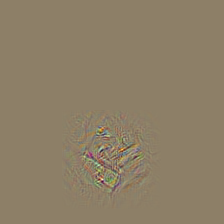

In [24]:
inv_normalize = T.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.255],
    std=[1/0.229, 1/0.224, 1/0.255]
)
def to_0_1(image_t: torch.Tensor) -> torch.Tensor:
    return (image_t - image_t.min()) / (image_t.max() - image_t.min())
output_deconv_in_pixel_space = to_0_1(inv_normalize(tensor[0]))
img1 = T.functional.to_pil_image(output_deconv_in_pixel_space)
display(img1)

## Création du dictionnaire vérité terrain "idx fichier vers label"

In [9]:
from ILSVRC2012_synsets import ILSVRC2012_synsets_idx_to_codes
from imagenet_labels import imagenet1K_codes_to_labels
def read_imagenet_classes_ground_truth(file_path = "ILSVRC2012_validation_ground_truth.txt"):
    with open(file_path, 'r') as f:
        class_ids = [int(line.strip()) for line in f if line.strip().isdigit()]
    return class_ids

# Exemple d'utilisation
imagenet_classes_ground_truth = read_imagenet_classes_ground_truth()
with open("imagenet_classes_ground_truth_labels_2.txt", "a") as f:
    for i, idx_gt in enumerate(imagenet_classes_ground_truth):
        code = ILSVRC2012_synsets_idx_to_codes[idx_gt]
        idx_label = imagenet1K_codes_to_labels[code]
        print(f"{i+1}: {idx_label},")
        f.write(f"{i+1}: {idx_label},\n")

1: 65,
2: 970,
3: 230,
4: 809,
5: 516,
6: 57,
7: 334,
8: 415,
9: 674,
10: 332,
11: 109,
12: 286,
13: 370,
14: 757,
15: 595,
16: 147,
17: 108,
18: 23,
19: 478,
20: 517,
21: 334,
22: 173,
23: 948,
24: 727,
25: 23,
26: 846,
27: 270,
28: 167,
29: 55,
30: 858,
31: 324,
32: 573,
33: 150,
34: 981,
35: 586,
36: 887,
37: 32,
38: 398,
39: 777,
40: 74,
41: 516,
42: 756,
43: 129,
44: 198,
45: 256,
46: 725,
47: 565,
48: 167,
49: 717,
50: 394,
51: 92,
52: 29,
53: 844,
54: 591,
55: 358,
56: 468,
57: 259,
58: 994,
59: 872,
60: 588,
61: 474,
62: 183,
63: 107,
64: 46,
65: 842,
66: 390,
67: 101,
68: 887,
69: 870,
70: 841,
71: 467,
72: 149,
73: 21,
74: 476,
75: 80,
76: 424,
77: 159,
78: 275,
79: 175,
80: 461,
81: 970,
82: 160,
83: 788,
84: 58,
85: 479,
86: 498,
87: 369,
88: 28,
89: 487,
90: 50,
91: 270,
92: 383,
93: 366,
94: 780,
95: 373,
96: 705,
97: 330,
98: 142,
99: 949,
100: 349,
101: 473,
102: 159,
103: 872,
104: 878,
105: 201,
106: 906,
107: 70,
108: 486,
109: 632,
110: 608,
111: 122,
112: 720,
113: